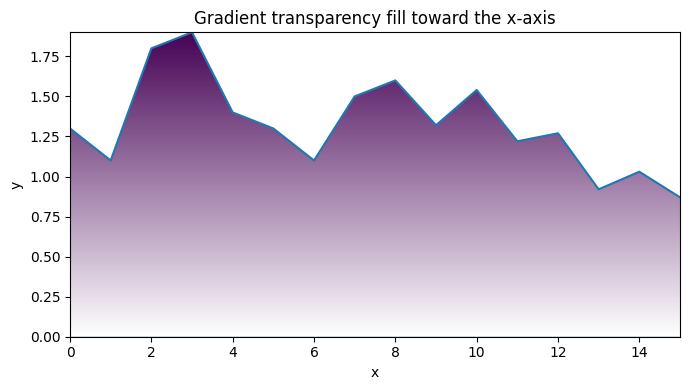

In [2]:
# Demo: gradient transparency fill under a line toward the x-axis using matplotlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch

def gradient_fill_toward_xaxis(ax, x, y, y0=0.0, ny=400):
    """
    Fill the area between y(x) and baseline y0 with a vertical alpha gradient:
    closer to the x-axis (baseline) = more transparent; farther = more opaque.
    
    Parameters
    ----------
    ax : matplotlib Axes
    x, y : 1D arrays defining the curve
    y0 : float, baseline (default 0.0 for the x-axis)
    ny : int, vertical resolution for the gradient raster
    """
    x = np.asarray(x)
    y = np.asarray(y)
    assert x.ndim == y.ndim == 1 and x.size == y.size
    
    # Build the polygon path for the under-curve area
    verts = np.concatenate([np.column_stack([x, y]),
                            np.column_stack([x[::-1], np.full_like(x, y0)[::-1]])])
    codes = np.concatenate([[Path.MOVETO], np.full(len(x)-1, Path.LINETO),
                            np.full(len(x), Path.LINETO)])
    path = Path(verts, codes)
    patch = PathPatch(path, facecolor="none", edgecolor="none")
    ax.add_patch(patch)
    
    # Gradient image: we paint a rectangle from y0 to y.max()
    ymin = min(y0, y.min(), 0.0)
    ymax = max(y0, y.max())
    ny = int(ny)
    nx = max(200, len(x))
    
    # Alpha increases with distance above baseline (y0)
    yy = np.linspace(y0, ymax, ny)[:, None]  # column vector
    # Normalize opacity: 0 at y0, 1 at ymax
    # Avoid division by zero:
    denom = (ymax - y0) if (ymax - y0) != 0 else 1.0
    alpha_col = np.clip((yy - y0) / denom, 0, 1)
    alpha_img = np.repeat(alpha_col, nx, axis=1)  # 2D alpha mask
    
    # Use a constant-valued image (color chosen by default colormap);
    # opacity is controlled solely by alpha_img
    img = np.ones((ny, nx))
    
    im = ax.imshow(
        img,
        origin="lower",
        extent=(x.min(), x.max(), y0, ymax),
        aspect="auto",
        alpha=alpha_img
    )
    # Clip the gradient rectangle to the area under the curve
    im.set_clip_path(patch)
    
    # Draw the curve on top
    ax.plot(x, y)
    ax.axhline(y0, linewidth=1)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(ymin, ymax)

# Example data: smooth positive curve
x = np.linspace(0, 15, 16)
y = [1.3, 1.1, 1.8,1.9,1.4,1.3,1.1,1.5,1.6,1.32,1.54,1.22,1.27,0.92,1.03,0.87]

fig, ax = plt.subplots(figsize=(7, 4))
gradient_fill_toward_xaxis(ax, x, y, y0=0.0, ny=500)
ax.set_title("Gradient transparency fill toward the x-axis")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()


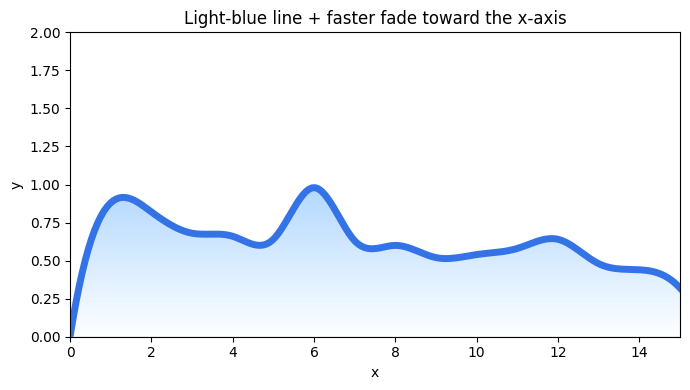

In [3]:
# Update: light-blue theme and faster transparency fade toward the x-axis
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from scipy.interpolate import CubicSpline

def gradient_fill_toward_xaxis(ax, x, y, y0=0.0, ny=400, 
                               fill_rgb=(0.70, 0.85, 1.00),  # light blue
                               line_rgb=(0.20, 0.45, 0.90),  # darker blue for the curve
                               gamma=0.5):
    """
    Fill area under y(x) down to baseline y0 with a vertical alpha gradient.
    Color theme is controlled via fill_rgb/line_rgb. A larger `gamma` fades 
    faster toward the baseline (i.e., becomes transparent more quickly).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    
    # polygon for clipping
    verts = np.concatenate([np.column_stack([x, y]),
                            np.column_stack([x[::-1], np.full_like(x, y0)[::-1]])])
    codes = np.concatenate([[Path.MOVETO], np.full(len(x)-1, Path.LINETO),
                            np.full(len(x), Path.LINETO)])
    path = Path(verts, codes)
    patch = PathPatch(path, facecolor="none", edgecolor="none")
    ax.add_patch(patch)
    
    # gradient canvas
    ymin = min(y0, y.min(), 0.0)
    ymax = max(y0, y.max())
    ny = int(ny)
    nx = max(200, len(x))
    
    # alpha increases with distance above baseline; gamma>1 makes it fade faster near the baseline
    yy = np.linspace(y0, ymax, ny)[:, None]
    denom = (ymax - y0) if (ymax - y0) != 0 else 1.0
    t = np.clip((yy - y0) / denom, 0, 1)
    alpha_col = t**gamma
    alpha_img = np.repeat(alpha_col, nx, axis=1)
    
    # constant RGB image in the chosen light-blue color
    img = np.ones((ny, nx, 3), dtype=float)
    img[..., 0] *= fill_rgb[0]
    img[..., 1] *= fill_rgb[1]
    img[..., 2] *= fill_rgb[2]
    
    im = ax.imshow(
        img,
        origin="lower",
        extent=(x.min(), x.max(), y0, ymax),
        aspect="auto",
        alpha=alpha_img
    )
    im.set_clip_path(patch)
    
    # curve and baseline
    ax.plot(x, y, linewidth=5, color=line_rgb)
    ax.axhline(y0, linewidth=1, color=(0.75, 0.85, 0.95))
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(ymin, ymax)

# Example
x = np.linspace(0, 15,16)
y_samples = np.array([
    0, 0.88, 0.82, 0.68, 0.66, 0.64, 0.98, 0.63, 0.60,
    0.52, 0.54, 0.58, 0.64, 0.48, 0.44, 0.32
], dtype=float)

spline = CubicSpline(x, y_samples)
x = np.linspace(x.min(), x.max(), 200)
y = spline(x)

fig, ax = plt.subplots(figsize=(7, 4))

gradient_fill_toward_xaxis(ax, x, y, y0=0.0, ny=600, gamma=1.0)  # stronger fade
ax.set_title("Light-blue line + faster fade toward the x-axis")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(0,2)
plt.tight_layout()
plt.show()


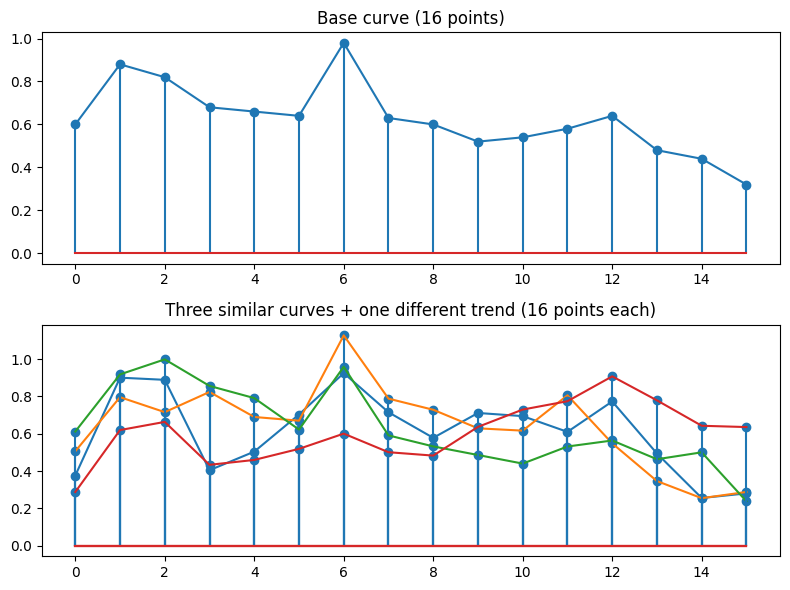

In [4]:
# Generate 3 sequences similar to the provided 16-point curve,
# plus 1 sequence with a very different trend. Show a table and plots,
# and save as CSV for download.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Base curve (16 points)
base = np.array([0.60, 0.88, 0.82, 0.68, 0.66, 0.64, 0.98, 0.63, 
                 0.60, 0.52, 0.54, 0.58, 0.64, 0.48, 0.44, 0.32], dtype=float)

rng = np.random.default_rng(42)

def make_similar(curve, noise_scale=0.04, drift_scale=0.02, peak_jitter=0.03):
    x = np.arange(len(curve))
    # small smooth drift (low-frequency)
    drift = drift_scale * np.sin(2*np.pi*(x/len(curve) + rng.uniform()))
    # small local noise
    noise = rng.normal(0.0, noise_scale, size=len(curve))
    y = curve + drift + noise
    # keep the main peak area similar by nudging around indices near the original peak (6-7)
    y[6] += rng.normal(0.0, peak_jitter)
    y = np.clip(y, 0.0, 1.2)  # keep in reasonable range
    return y

sim1 = make_similar(base, noise_scale=0.13, drift_scale=0.09, peak_jitter=0.09)
sim2 = make_similar(base, noise_scale=0.11, drift_scale=0.10, peak_jitter=0.08)
sim3 = make_similar(base, noise_scale=0.09, drift_scale=0.12, peak_jitter=0.12)

# A very different trend: steadily increasing with a late small oscillation
x = np.linspace(0, 1, len(base))
trend_diff = 0.2 + 0.9*x**1.5 + 0.2*np.sin(10*x)
trend_diff = np.clip(trend_diff, 0.0, 1.2)

trend_diff = (trend_diff + sim1)/2

# Plot: stem+line for each sequence
n = len(base)
xs = np.arange(n)

plt.figure(figsize=(8, 6))

# Base
plt.subplot(2, 1, 1)
plt.stem(xs, base)
plt.plot(xs, base)
plt.title("Base curve (16 points)")

# Others
plt.subplot(2, 1, 2)
plt.stem(xs, sim1)
plt.plot(xs, sim1, label="sim1")
plt.stem(xs, sim2 )
plt.plot(xs, sim2, label="sim2")
plt.stem(xs, sim3)
plt.plot(xs, sim3, label="sim3")
plt.stem(xs, trend_diff)
plt.plot(xs, trend_diff, label="different trend")
plt.title("Three similar curves + one different trend (16 points each)")
plt.tight_layout()
plt.show()



In [5]:
sim1

array([0.37581968, 0.90051424, 0.88889629, 0.40478177, 0.50421239,
       0.70313977, 0.925052  , 0.71518945, 0.57808668, 0.71136615,
       0.69449008, 0.61016765, 0.77304563, 0.4942557 , 0.25582901,
       0.280564  ])

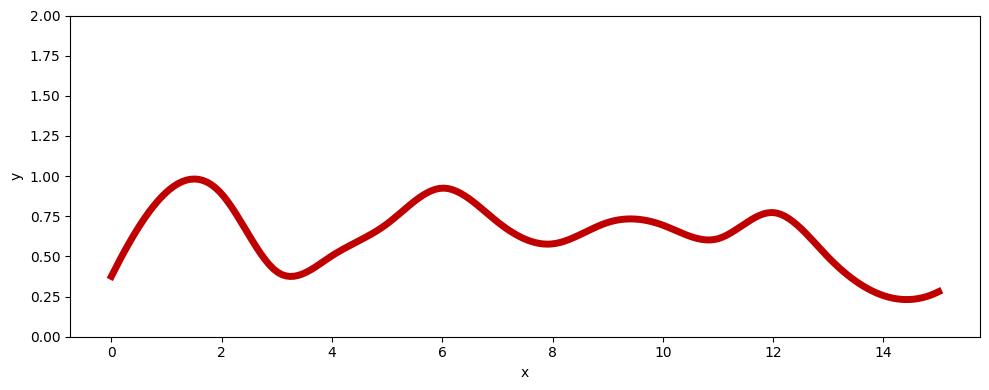

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from scipy.interpolate import CubicSpline
x = np.linspace(0, 15,16)
y_samples = np.array([
    0.6, 0.88, 0.82, 0.68, 0.66, 0.64, 0.98, 0.63, 0.60,
    0.52, 0.54, 0.58, 0.64, 0.48, 0.44, 0.32
], dtype=float)

spline = CubicSpline(x, sim1)
x = np.linspace(x.min(), x.max(), 200)
y = spline(x)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, color="#C00000", linewidth=5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(0,2)
plt.tight_layout()
plt.show()

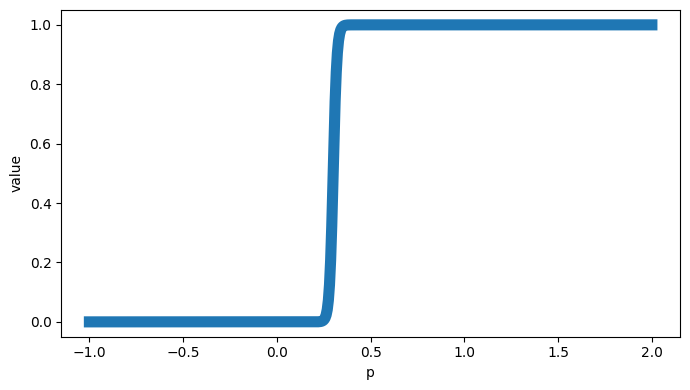

In [7]:
import torch
import matplotlib.pyplot as plt

sharpness_k = torch.tensor(100.0)
threshold = torch.tensor(0.3)

p = torch.linspace(-1, 2, 500)
response = torch.sigmoid(sharpness_k * (p - threshold))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p.numpy(), response.numpy(), linewidth=8, color="#1f77b4", label="sigmoid")
# ax.axvline(threshold.item(), color="#ff7f0e", linestyle="--", label="threshold")
ax.set_xlabel("p")
ax.set_ylabel("value")
# ax.set_title(r"$\mathrm{sigmoid}(k \cdot (p - \theta))$")
# ax.legend()
plt.tight_layout()
plt.show()

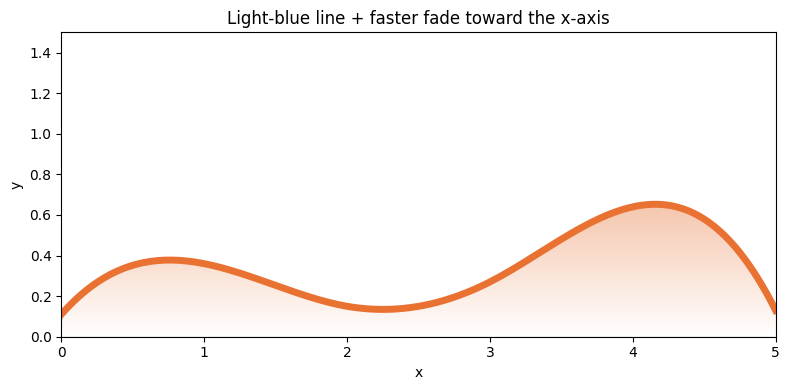

In [10]:
x = np.linspace(0, 5, 6)
y_samples = np.array([0.11, 0.36, 0.15, 0.27, 0.64, 0.13], dtype=float)

spline = CubicSpline(x, y_samples)
x = np.linspace(x.min(), x.max(), 200)
y = spline(x)

fig, ax = plt.subplots(figsize=(8, 4))
gradient_fill_toward_xaxis(
    ax,
    x,
    y,
    y0=0.0,
    ny=600,
    fill_rgb=(246/255, 198/255, 173/255),
    line_rgb=(233/255, 113/255, 50/255),
    gamma=1.0,
)
ax.set_title("Light-blue line + faster fade toward the x-axis")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(0, 1.5)
plt.tight_layout()
plt.show()
